In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## Part 1: Histogram Equalization (Grayscale)

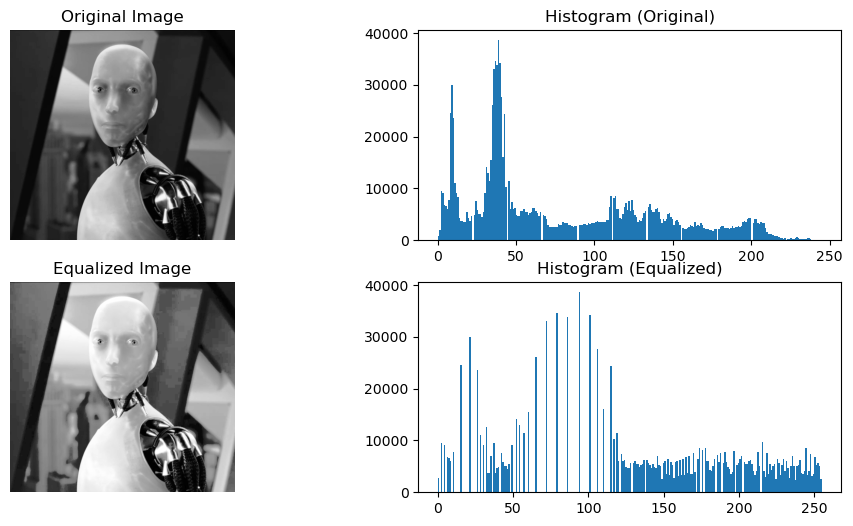

In [25]:
gray_img = cv2.imread('/Users/230150/Downloads/robot.jpeg', cv2.IMREAD_GRAYSCALE)

eq_img = cv2.equalizeHist(gray_img)

# Display results
plt.figure(figsize=(12,6))

plt.subplot(2,2,1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(2,2,2)
plt.hist(gray_img.flatten(), bins = 256)
plt.title("Histogram (Original)")

plt.subplot(2,2,3)
plt.imshow(equalized_image, cmap='gray')
plt.title("Equalized Image")
plt.axis('off')

plt.subplot(2,2,4)
plt.hist(eq_img.flatten(), bins = 256)
plt.title("Histogram (Equalized)")

plt.show()

### Short Explanation
Histogram equalization spreads pixel intensities across the full range, making dark areas brighter and improving contrast in poorly lit images.

## Part 2: Histogram Equalization on Color Images

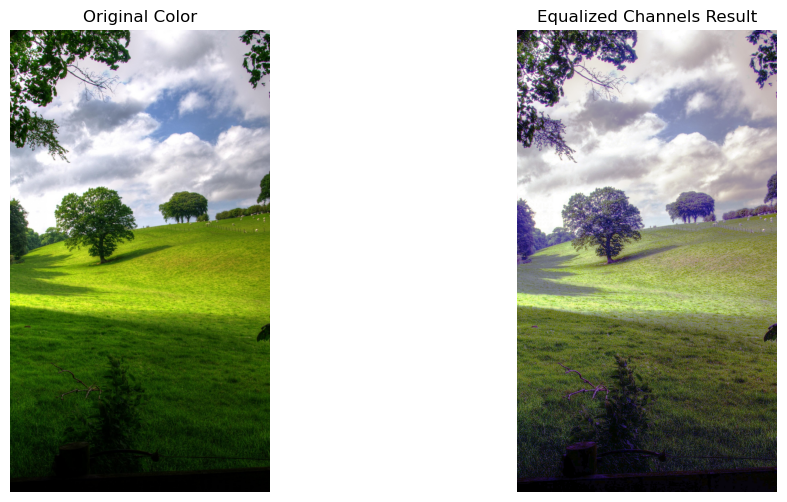

In [31]:
import cv2
import matplotlib.pyplot as plt

color_img = cv2.imread('/Users/230150/Downloads/bright.jpg')

blue, green, red = cv2.split(color_img)

# Equalize each channel
eq_blue = cv2.equalizeHist(b)
eq_green = cv2.equalizeHist(g)
eq_red = cv2.equalizeHist(r)

# Merge channels
equalized_color = cv2.merge([eq_blue, eq_green, eq_red])

plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(color_img, cv2.COLOR_BGR2RGB))
plt.title("Original Color")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(equalized_color, cv2.COLOR_BGR2RGB))
plt.title("Equalized Channels Result")
plt.axis('off')

plt.show()

### Short explanation 
**1. Performing per-channel equalization:**  
Each B, G, R channel is equalized with its own CDF. Because the three channels have different distributions, the equalization shift is different for each, altering their relative balance.

**2. Changes in color balance:**  
The equalized image shows increased brightness and contrast overall, but the color balance shifts noticeably — it may appear over-saturated or with an unnatural hue. This happens because the luminance is not preserved; only per-channel stretching occurs. A better approach for color images is to convert to **YCrCb** or **HSV**, equalize only the luminance (Y or V) channel, then convert back, which preserves hue.

## Part 3: Histogram Matching (Specification)

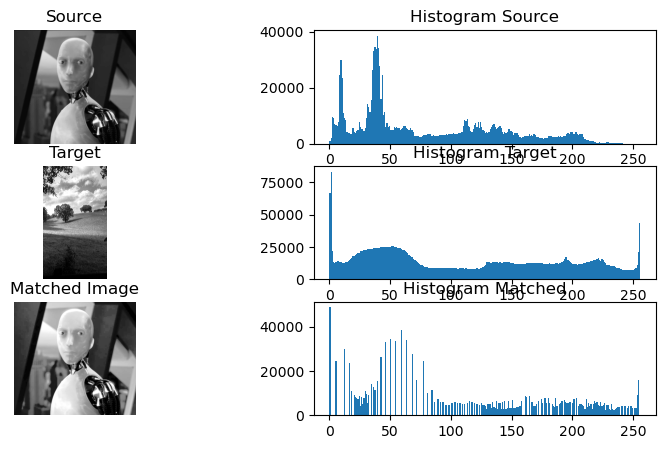

In [29]:
import cv2
import matplotlib.pyplot as plt
from skimage import exposure

# Read images
source_img = cv2.imread('/Users/230150/Downloads/robot.jpeg', cv2.IMREAD_GRAYSCALE)
target_img = cv2.imread('/Users/230150/Downloads/bright.jpg', cv2.IMREAD_GRAYSCALE)

# Histogram matching
matched = exposure.match_histograms(source_img, target_img)

plt.figure(figsize=(15,5))

plt.subplot(3,3,1)
plt.imshow(source, cmap='gray')
plt.title("Source")
plt.axis('off')

plt.subplot(3,3,2)
plt.hist(source.ravel(),256,[0,256])
plt.title("Histogram Source")

plt.subplot(3,3,4)
plt.imshow(target, cmap='gray')
plt.title("Target")
plt.axis('off')

plt.subplot(3,3,5)
plt.hist(target.ravel(),256,[0,256])
plt.title("Histogram Target")

plt.subplot(3,3,7)
plt.imshow(matched, cmap='gray')
plt.title("Matched Image")
plt.axis('off')

plt.subplot(3,3,8)
plt.hist(matched.ravel(),256,[0,256])
plt.title("Histogram Matched")

plt.show()

**Explain how histogram matching affects the visual appearance of the source image.**

Histogram matching changes the brightness and contrast of the source image so that it looks similar to the target image. The intensity values are adjusted to follow the same distribution as the reference image. As a result, the overall lighting and tonal appearance change, but the objects and structure of the image remain the same.

## Part 4: Combining Histogram Equalization and Matching

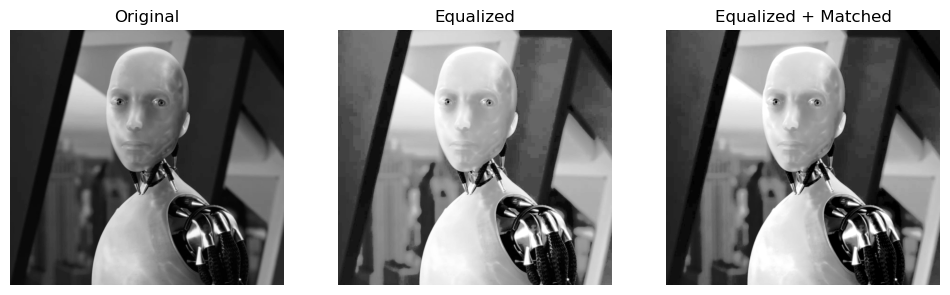

In [19]:
equalized = cv2.equalizeHist(source)

# Histogram matching
final_result = exposure.match_histograms(equalized, target)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(source, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(equalized, cmap='gray')
plt.title("Equalized")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(final_result, cmap='gray')
plt.title("Equalized + Matched")
plt.axis('off')

plt.show()

**Discuss how equalization followed by matching alters the appearance of the original image.**

Histogram equalization first increases contrast and makes hidden details more visible. After that, histogram matching adjusts the brightness and intensity distribution to resemble the target image. As a result, the image becomes clearer while also looking more natural and visually balanced.

### Brief Report

Histogram equalization and histogram matching were used to improve image quality. Histogram equalization enhances image contrast by redistributing pixel intensities across the full intensity range. This makes dark areas brighter and reveals more details, especially in poorly illuminated images.

Histogram matching modifies the brightness distribution of a source image so that it becomes similar to a target image. This helps achieve consistent brightness and contrast between images.

Overall, histogram equalization improves contrast, while histogram matching adjusts brightness and intensity distribution to produce a more natural and visually balanced result.